Imports

In [10]:
import pandas as pd
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import folium 
import geopandas as gp

Get usefull first informations on the dataset

In [11]:
data = pd.read_csv('excel_project_s2.csv',sep=',',index_col=0,decimal='.')
data.head(),data.info(),data.describe(),data.dtypes,data.columns

<class 'pandas.DataFrame'>
Index: 150 entries, CA-2016-152156 to CA-2016-114489
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Customer ID                        150 non-null    str  
 1   Customer Name                      150 non-null    str  
 2   Product ID                         150 non-null    str  
 3   Product Name                       150 non-null    str  
 4   Postal Code                        150 non-null    int64
 5   City                               150 non-null    str  
 6   State                              150 non-null    str  
 7   Order Date                         150 non-null    str  
 8    Total Amount                      150 non-null    str  
 9   Quantity                           150 non-null    int64
 10  Discount                           150 non-null    str  
 11  Ship Date                          150 non-null    str  
 12  Category      

(               Customer ID    Customer Name       Product ID  \
 Order ID                                                       
 CA-2016-152156    CG-12520      Claire Gute  FUR-BO-10001798   
 CA-2016-152156    CG-12520      Claire Gute  FUR-CH-10000454   
 US-2015-108966    SO-20335   Sean O'Donnell  FUR-TA-10000577   
 US-2015-108966    SO-20335   Sean O'Donnell  OFF-ST-10000760   
 CA-2016-138688    DV-13045  Darrin Van Huff  OFF-LA-10000240   
 
                                                      Product Name  \
 Order ID                                                            
 CA-2016-152156                  Bush Somerset Collection Bookcase   
 CA-2016-152156  Hon Deluxe Fabric Upholstered Stacking Chairs,...   
 US-2015-108966      Bretford CR4500 Series Slim Rectangular Table   
 US-2015-108966                     Eldon Fold 'N Roll Cart System   
 CA-2016-138688  Self-Adhesive Address Labels for Typewriters b...   
 
                 Postal Code              City     

Changing date datatype to pandas datetime64 type

In [12]:
data["Ship Date"] = pd.to_datetime(data["Ship Date"], format="%m/%d/%Y").dt.date
data["montant"] = (data[" Total Amount After the Discount "]
                 .astype(str)  # Assure string
                 .str.replace('$', '') # Espaces résiduels
                 .str.replace(" ", "")
                 .str.replace(",","")  # Enlève $
                 .str.strip()
                 )  
data["montant"] = pd.to_numeric(data["montant"])  # Conversion 

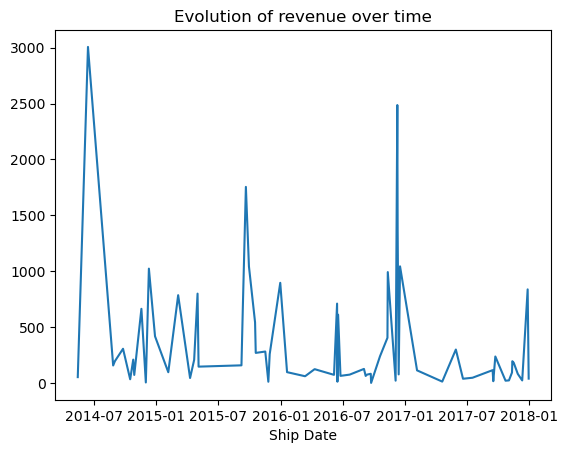

In [13]:
#Evolution du CA dans le temps
ax = data.groupby("Ship Date")["montant"].sum().plot(kind="line")
plt.title("Evolution of revenue over time")
plt.savefig("plots/evolution_CA.png", dpi=300, bbox_inches='tight')

In [14]:
filtre = data[data["montant"] > 1000]
print(filtre[["Customer ID","Ship Date","montant"]].sort_values(by="Ship Date",ascending=True))

               Customer ID   Ship Date  montant
Order ID                                       
CA-2014-115812    BH-11710  2014-06-14  1364.95
US-2015-150630    TB-21520  2015-09-21  1541.72
CA-2015-106320    EB-13870  2015-09-30  1044.63
CA-2016-114489    JE-16165  2016-12-09  1951.84
CA-2016-105816    JM-15265  2016-12-17  1029.95


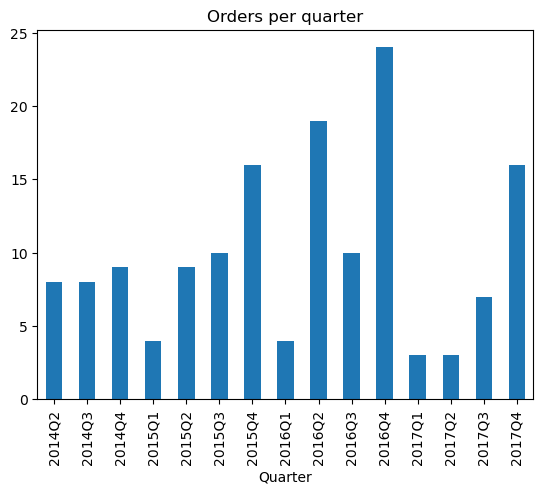

In [15]:
data['Ship Date'] = pd.to_datetime(
    data['Ship Date'],
    format='%m/%d/%Y',   # adapte si besoin
    errors='coerce'      # les dates invalides deviennent NaT
)
data['Quarter'] = data['Ship Date'].dt.to_period('Q')
quarterly = data.groupby('Quarter')['montant'].count()

quarterly.plot(kind='bar', legend=False)
plt.title('Orders per quarter')
plt.savefig('plots/evolution_orders.png', dpi=300, bbox_inches='tight')
plt.show()




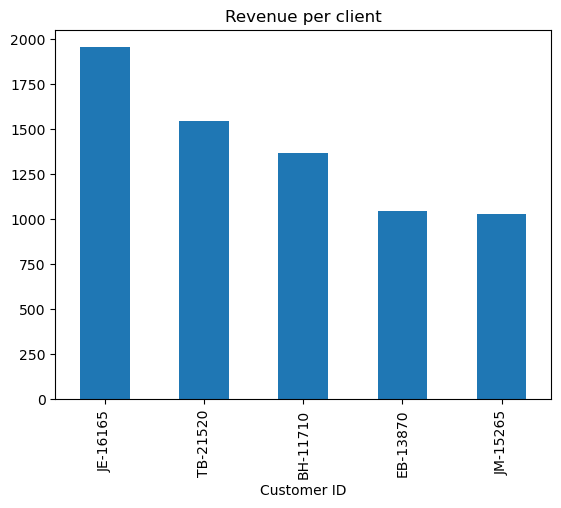

Mean of all orders :  169.6208
Number of orders by customer (top 10) : 
 Customer ID
TB-21520    8
LC-16885    7
TB-21055    7
BH-11710    7
SC-20725    5
SN-20710    4
JE-15745    4
KM-16720    4
RC-19960    4
DP-13000    4
Name: montant, dtype: int64
Mean of number of orders by customer :  2.1739130434782608


In [16]:
ax = filtre.groupby("Customer ID")["montant"].sum().sort_values(ascending=False).plot(kind="bar")
plt.title("Revenue per client")
plt.savefig("plots/CA_by_customer.png", dpi=300, bbox_inches='tight')
plt.show()
print("Mean of all orders : ",data["montant"].mean())
print("Number of orders by customer (top 10) : \n",data.groupby("Customer ID")["montant"].count().sort_values(ascending=False).head(10))
print("Mean of number of orders by customer : ",data.groupby("Customer ID")["montant"].count().mean())

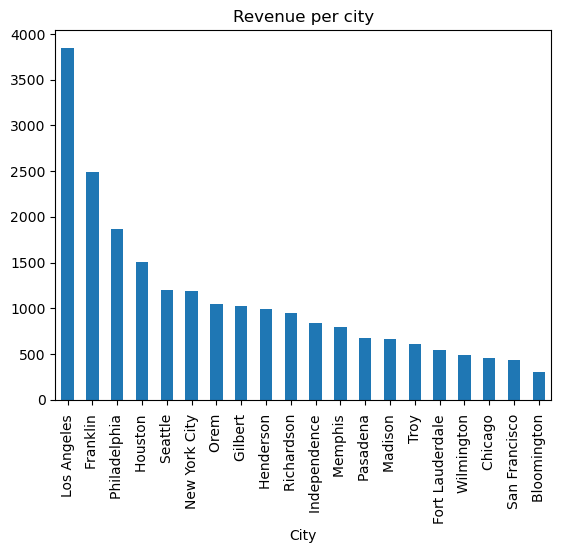

In [17]:
ax = data.groupby("City")["montant"].sum().sort_values(ascending=False)[:20].plot(kind="bar")
plt.title("Revenue per city")
plt.savefig("plots/CA_by_city.png", dpi=300, bbox_inches='tight')
plt.show()

In [18]:
US_CITIES_COORDS = {
    "Henderson": (36.0397, -114.9819), "Fort Lauderdale": (26.1224, -80.1373),
    "Los Angeles": (34.0522, -118.2437), "Fort Worth": (32.7555, -97.3308),
    "Madison": (43.0731, -89.4012), "San Francisco": (37.7749, -122.4194),
    "Seattle": (47.6062, -122.3321), "Philadelphia": (39.9526, -75.1652),
    "Houston": (29.7604, -95.3698), "New York City": (40.7128, -74.0060),
    "Chicago": (41.8781, -87.6298), "Phoenix": (33.4484, -112.0740),
    "Columbus": (39.9612, -82.9988), "Nashville": (36.1627, -86.7816),
    "Denver": (39.7392, -104.9903), "Atlanta": (33.7490, -84.3880),
    "Portland": (45.5051, -122.6750), "San Diego": (32.7157, -117.1611),
    "Dallas": (32.7767, -96.7970), "Austin": (30.2672, -97.7431),
    "Jacksonville": (30.3322, -81.6557), "Charlotte": (35.2271, -80.8431),
    "Indianapolis": (39.7684, -86.1581), "Memphis": (35.1495, -90.0490),
    "Baltimore": (39.2904, -76.6122), "Boston": (42.3601, -71.0589),
    "Louisville": (38.2527, -85.7585), "Milwaukee": (43.0389, -87.9065),
    "Albuquerque": (35.0844, -106.6504), "Tucson": (32.2226, -110.9747),
    "Fresno": (36.7378, -119.7871), "Sacramento": (38.5816, -121.4944),
    "Mesa": (33.4152, -111.8315), "Kansas City": (39.0997, -94.5786),
    "Omaha": (41.2565, -95.9345), "Raleigh": (35.7796, -78.6382),
    "Miami": (25.7617, -80.1918), "Minneapolis": (44.9778, -93.2650),
    "Tulsa": (36.1540, -95.9928), "Cleveland": (41.4993, -81.6944),
    "Wichita": (37.6872, -97.3301), "Arlington": (32.7357, -97.1081),
    "New Orleans": (29.9511, -90.0715), "Tampa": (27.9506, -82.4572),
    "Aurora": (39.7294, -104.8319), "Anaheim": (33.8366, -117.9143),
    "Corpus Christi": (27.8006, -97.3964), "Santa Ana": (33.7455, -117.8677),
    "Riverside": (33.9806, -117.3755), "St. Louis": (38.6270, -90.1994),
    "Lexington": (38.0406, -84.5037), "Pittsburgh": (40.4406, -79.9959),
    "Stockton": (37.9577, -121.2908), "Anchorage": (61.2181, -149.9003),
    "Cincinnati": (39.1031, -84.5120), "St. Paul": (44.9537, -93.0900),
    "Toledo": (41.6639, -83.5552), "Greensboro": (36.0726, -79.7920),
    "Newark": (40.7357, -74.1724), "Plano": (33.0198, -96.6989),
    "Henderson": (36.0397, -114.9819), "Lincoln": (40.8136, -96.7026),
    "Buffalo": (42.8864, -78.8784), "Fort Wayne": (41.1306, -85.1289),
    "Jersey City": (40.7178, -74.0431), "Chula Vista": (32.6401, -117.0842),
    "Orlando": (28.5383, -81.3792), "St. Petersburg": (27.7676, -82.6403),
    "Norfolk": (36.8508, -76.2859), "Chandler": (33.3062, -111.8413),
    "Laredo": (27.5064, -99.5075), "Madison": (43.0731, -89.4012),
    "Durham": (35.9940, -78.8986), "Lubbock": (33.5779, -101.8552),
    "Winston-Salem": (36.0999, -80.2442), "Garland": (32.9126, -96.6389),
    "Glendale": (33.5387, -112.1860), "Hialeah": (25.8576, -80.2781),
    "Reno": (39.5296, -119.8138), "Baton Rouge": (30.4515, -91.1871),
    "Irvine": (33.6846, -117.8265), "Chesapeake": (36.7682, -76.2875),
    "Scottsdale": (33.4942, -111.9261), "North Las Vegas": (36.1989, -115.1175),
    "Fremont": (37.5485, -121.9886), "Gilbert": (33.3528, -111.7890),
    "San Bernardino": (34.1083, -117.2898), "Birmingham": (33.5207, -86.8025),
    "Rochester": (43.1566, -77.6088), "Richmond": (37.5407, -77.4360)
}
US_CITIES_COORDS.update({
    "Decatur":      (39.8403, -88.9548),
    "Naperville":   (41.7508, -88.1535),
    "Columbia":     (38.9517, -92.3341),
    "Orland Park":  (41.6303, -87.8539),
    "Concord":      (35.4088, -80.5795),
    "Richardson":   (32.9483, -96.7299),
    "Franklin":     (35.9251, -86.8689),
    "Urbandale":    (41.6267, -93.7122),
    "Springfield":  (39.7817, -89.6501),
    "Bloomington":  (40.4842, -88.9937),
    "Roseville":    (38.7521, -121.2880),
    "Eagan":        (44.8041, -93.1669),
    "Pasadena":     (34.1478, -118.1445),
    "Saint Paul":   (44.9537, -93.0900),
    "Jackson":      (32.2988, -90.1848),
    "Wilmington":   (34.2257, -77.9447),
    "Melbourne":    (28.0836, -80.6081),
    "New Albany":   (38.2859, -85.8241),
    "Independence": (39.0911, -94.4155),
    "West Jordan":  (40.6097, -111.9391),
    "Troy":         (42.6064, -83.1498),
    "Bristol":      (36.5951, -82.1887),
    "Dover":        (39.1582, -75.5244),
    "Orem":         (40.2969, -111.6946),
    "Westland":     (42.3242, -83.4002),
})
data["City"] = data["City"].str.strip()

city_sales = data.groupby("City")["montant"].sum().reset_index()
city_sales.columns = ["City", "Revenue"]

city_sales["lat"] = city_sales["City"].map(lambda c: US_CITIES_COORDS.get(c, (None, None))[0])
city_sales["lon"] = city_sales["City"].map(lambda c: US_CITIES_COORDS.get(c, (None, None))[1])
city_sales = city_sales.dropna(subset=["lat", "lon"])

# Diagnostic : combien de villes ont matché ?
print(f"✅ {len(city_sales)} villes matchées sur {data['City'].nunique()} uniques")
print("Villes non trouvées :", set(data["City"].unique()) - set(city_sales["City"]))

# Carte
m = folium.Map(location=[39.5, -98.35], zoom_start=4, tiles="CartoDB positron")

for _, row in city_sales.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=row["Revenue"] / city_sales["Revenue"].max() * 20 + 5,
        popup=f"{row['City']} : ${row['Revenue']:,.0f}",
        color="steelblue",
        fill=True,
        fill_opacity=0.6
    ).add_to(m)

m.save("carte_ventes.html")
print("✅ Carte sauvegardée")

✅ 48 villes matchées sur 48 uniques
Villes non trouvées : set()
✅ Carte sauvegardée
